# Final Regression Model Comparison

## Notebook Objective

This notebook compares all regression models tested in the monthly cost prediction project.

The goal is to identify the strongest overall regression model based on held-out test-set performance.

Models are compared using MAE, RMSE, and R².

RMSE is treated as the primary selection metric because healthcare cost prediction is sensitive to large errors, especially among high-cost members.

This notebook focuses on final model comparison and model-selection reasoning, not new model training.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

## 2. Manually enter model results

In [2]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest",
        "Gradient Boosting",
        "Tuned Gradient Boosting"
    ], 
    "Test MAE": [
        404.20, 
        404.17,
        404.14,
        449.41,
        393.13,
        392.53,
        370.87,
        374.69
    

        
    ],
    "Test RMSE": [
        654.27,
        654.24,
        654.21,
        709.09,
        668.22,
        668.57,
        643.58,
        644.50

    ],
    "Test R²": [
        0.764,
        0.764,
        0.764,
        0.723,
        0.754,
        0.753,
        0.772,
        0.771
    ]
})

## Model Results Source

The model results were manually collected from the prior regression notebooks.

Each value represents held-out test-set performance from the corresponding notebook.

Because these values are manually entered, they should be checked against the final version of each notebook before committing.

The comparison is only valid if all models used the same target variable, same cleaned feature set, and comparable train/test split logic.

## 3. Sort By RMSE

In [3]:
model_results_sorted = model_results.sort_values(
    by = "Test RMSE",
    ascending = True
) # Lower RMSE is better

model_results_sorted

,Model,Test MAE,Test RMSE,Test R²
6,Gradient Boosting,370.87,643.58,0.772
7,Tuned Gradient Boosting,374.69,644.50,0.771
2,Lasso Regression,404.14,654.21,0.764
1,Ridge Regression,404.17,654.24,0.764
0,Linear Regression,404.20,654.27,0.764
4,Random Forest,393.13,668.22,0.754
5,Tuned Random Forest,392.53,668.57,0.753
3,Decision Tree,449.41,709.09,0.723


## 4. Add model ranking

In [4]:
model_results_sorted["RMSE Rank"] = model_results_sorted["Test RMSE"].rank(ascending = True).astype(int) # Rank models by RMSE

model_results_sorted["MAE Rank"] = model_results_sorted["Test MAE"].rank(ascending = True).astype(int) # Rank models by MAE

model_results_sorted["R² Rank"] = model_results_sorted["Test R²"].rank(ascending = False).astype(int) # Rank models by R² (higher is better)

model_results_sorted

,Model,Test MAE,Test RMSE,Test R²,RMSE Rank,MAE Rank,R² Rank
6,Gradient Boosting,370.87,643.58,0.772,1,1,1
7,Tuned Gradient Boosting,374.69,644.50,0.771,2,2,2
2,Lasso Regression,404.14,654.21,0.764,3,5,4
1,Ridge Regression,404.17,654.24,0.764,4,6,4
0,Linear Regression,404.20,654.27,0.764,5,7,4
4,Random Forest,393.13,668.22,0.754,6,4,6
5,Tuned Random Forest,392.53,668.57,0.753,7,3,7
3,Decision Tree,449.41,709.09,0.723,8,8,8


## Ranking Interpretation

Gradient Boosting ranked first by RMSE, MAE, and R².

Tuned Gradient Boosting ranked second, but it did not improve over the baseline Gradient Boosting model in this run.

The regularized linear models performed very similarly to one another, with only tiny differences between Linear Regression, Ridge, and Lasso.

Random Forest improved over the controlled Decision Tree but did not outperform Gradient Boosting or the regularized linear models.

The single Decision Tree had the weakest overall performance among the final compared models.

## 5. Plot RMSE comparison

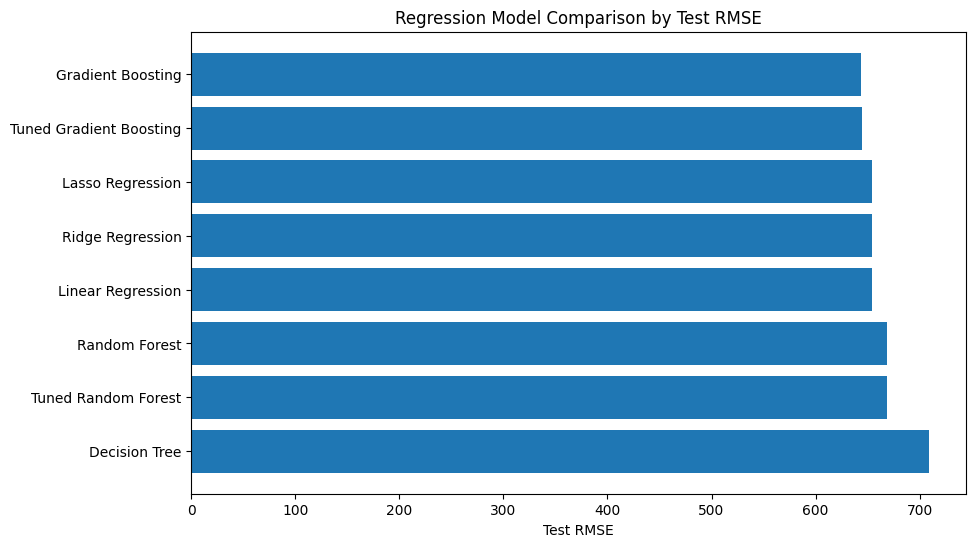

In [5]:
plt.figure(figsize=(10, 6))

plt.barh(
    model_results_sorted["Model"],
    model_results_sorted["Test RMSE"]
)

plt.xlabel("Test RMSE")
plt.title("Regression Model Comparison by Test RMSE")

plt.gca().invert_yaxis() # Best model appears at the top

plt.show()

## RMSE Comparison Interpretation

Gradient Boosting had the lowest test RMSE, making it the strongest model by the primary selection metric.

Tuned Gradient Boosting was very close but slightly worse.

The difference between Gradient Boosting and the regularized linear models is modest, while the Decision Tree is clearly weaker.

## 6. Plot MAE comparison

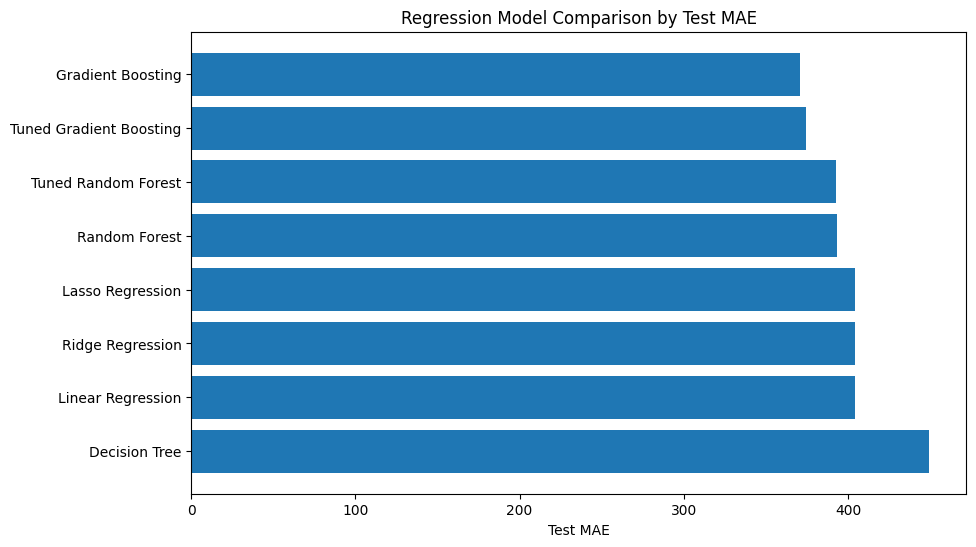

In [6]:
mae_sorted = model_results.sort_values(
    by="Test MAE",
    ascending=True
) # Lower MAE is better

plt.figure(figsize=(10, 6))

plt.barh(
    mae_sorted["Model"],
    mae_sorted["Test MAE"]
)

plt.xlabel("Test MAE")
plt.title("Regression Model Comparison by Test MAE")

plt.gca().invert_yaxis()

plt.show()

## MAE Comparison Interpretation

Gradient Boosting also had the lowest test MAE.

This means it had the lowest average absolute prediction error in dollar terms.

Random Forest had better MAE than the linear models, but its RMSE was worse, suggesting it may still have larger high-error cases.

## 7. Plot R² comparison

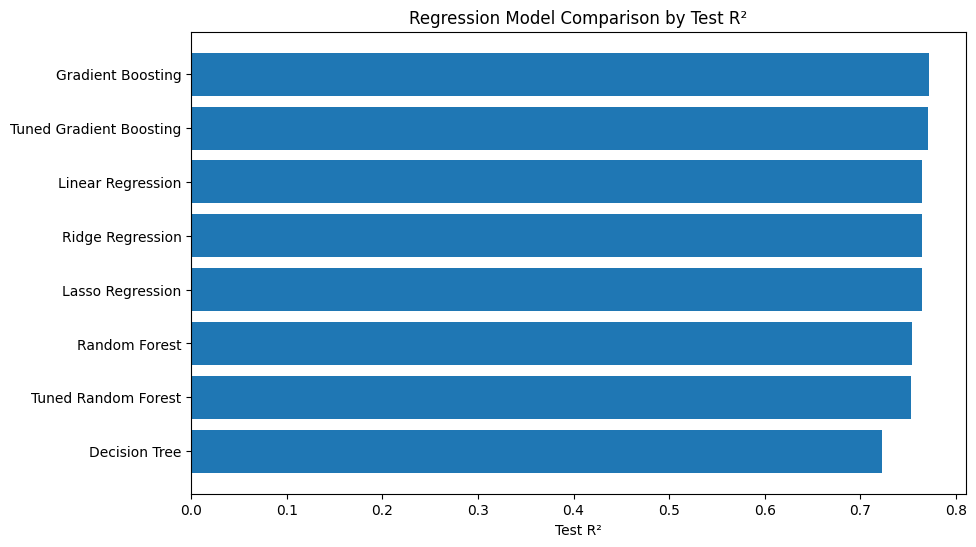

In [7]:
r2_sorted = model_results.sort_values(
    by="Test R²",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.barh(
    r2_sorted["Model"],
    r2_sorted["Test R²"]
)

plt.xlabel("Test R²")
plt.title("Regression Model Comparison by Test R²")

plt.gca().invert_yaxis()

plt.show()

## R² Comparison Interpretation

Gradient Boosting also had the highest R².

This means it explained the largest share of test-set variation in monthly cost among the compared models.

R² is useful as a supporting metric, but it should not be described as model accuracy.

## 8. Select final model

In [8]:
best_model_by_rmse = model_results_sorted.iloc[0] # select model with lowest RMSE

best_model_by_rmse

Model        Gradient Boosting
Test MAE                370.87
Test RMSE               643.58
Test R²                  0.772
RMSE Rank                    1
MAE Rank                     1
R² Rank                      1
Name: 6, dtype: object

## Final Model Selection

The final selected regression model is:

Gradient Boosting Regressor

Reason:
This model had the lowest test RMSE among the models compared.

Because monthly cost prediction is sensitive to large errors, RMSE is the primary model-selection metric.
MAE and R² were also reviewed as supporting metrics.

## Why the Tuned Gradient Boosting Model Was Not Selected

The tuned Gradient Boosting model performed almost the same as the baseline Gradient Boosting model, but it did not improve the primary metric.

The baseline Gradient Boosting model had slightly lower RMSE and MAE.

Because tuning did not produce a meaningful improvement, the simpler baseline Gradient Boosting model is selected as the final regression model.

This is a useful modeling lesson: tuning does not always improve test performance.

## 9. Interpretation framework

## Interpretation

The final model was selected based on test-set performance, not training performance.

Primary metric:
- RMSE

Supporting metrics:
- MAE
- R²

RMSE was prioritized because monthly healthcare cost prediction can be strongly affected by large prediction errors.

MAE was used to understand average absolute error in dollar terms.

R² was used to understand the proportion of variance explained by the model, but it was not used alone for model selection.

## 10. Important limitations

1. This project uses synthetic data, so the results reflect simulated healthcare cost patterns rather than real-world evidence.

2. The selected model is best only among the models tested in this project.

3. The comparison depends on manually collected results from prior notebooks, so metric values must match the final committed notebook outputs.

4. A model with the best RMSE is not automatically the best operational model if interpretability, stability, deployment simplicity, or business actionability matters more.

5. Feature importance and coefficients should not be interpreted causally.

6. Healthcare cost prediction is difficult because cost is right-skewed and high-cost cases are often driven by rare acute events.

7. The final model should be interpreted as a portfolio learning result, not a production-ready healthcare cost model.

## README Summary

This notebook compared all regression models developed for monthly cost prediction.

The compared models included Linear Regression, Ridge Regression, Lasso Regression, Decision Tree, Random Forest, Tuned Random Forest, Gradient Boosting, and Tuned Gradient Boosting.

Models were compared using held-out test-set MAE, RMSE, and R².

Gradient Boosting had the strongest overall test-set performance, with the lowest MAE, lowest RMSE, and highest R².

The tuned Gradient Boosting model did not materially improve over the baseline Gradient Boosting model.

The final selected model was the baseline Gradient Boosting Regressor.

The results are based on synthetic data and should be interpreted as model-comparison findings, not real-world causal evidence.